<a href="https://colab.research.google.com/github/bradkim1/Data_wrangling/blob/main/Data_wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load data file from Google Drive path (change the path to your actual file location)
file_path = '/content/drive/MyDrive/ML_Datasets/creditcardcsv.data'
df = pd.read_csv(file_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# Check total missing values in each column

print("Dataset shape:", df.shape)
print("\nData Types:\n", df.dtypes)

missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

if not missing_cols.empty:
    print("Columns with missing values:\n", missing_cols)
else:
    print("No missing values found.")

Dataset shape: (284807, 33)

Data Types:
 Time             float64
V1               float64
V2               float64
V3               float64
V4               float64
V5               float64
V6               float64
V7               float64
V8               float64
V9               float64
V10              float64
V11              float64
V12              float64
V13              float64
V14              float64
V15              float64
V16              float64
V17              float64
V18              float64
V19              float64
V20              float64
V21              float64
V22              float64
V23              float64
V24              float64
V25              float64
V26              float64
V27              float64
V28              float64
Amount           float64
Class              int64
Amount_scaled    float64
Time_scaled      float64
dtype: object
No missing values found.


In [34]:
#Check for malformed data
# Check for NaN or infinite values
has_nan = df.isna().any().any()
has_inf = np.isinf(df.values).any()

print(f"NaN present: {has_nan}")
print(f"Infinite values present: {has_inf}")

# Check column data types
print("Data types:\n", df.dtypes)

NaN present: False
Infinite values present: False
Data types:
 Time             float64
V1               float64
V2               float64
V3               float64
V4               float64
V5               float64
V6               float64
V7               float64
V8               float64
V9               float64
V10              float64
V11              float64
V12              float64
V13              float64
V14              float64
V15              float64
V16              float64
V17              float64
V18              float64
V19              float64
V20              float64
V21              float64
V22              float64
V23              float64
V24              float64
V25              float64
V26              float64
V27              float64
V28              float64
Amount           float64
Class              int64
Amount_scaled    float64
Time_scaled      float64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


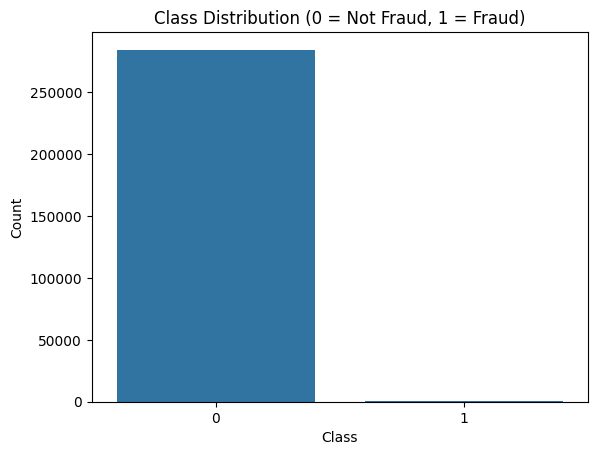

In [22]:
# Step 5: Descriptive statistics
display(df.describe())

# Step 6: Class distribution
class_counts = df['Class'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution (0 = Not Fraud, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

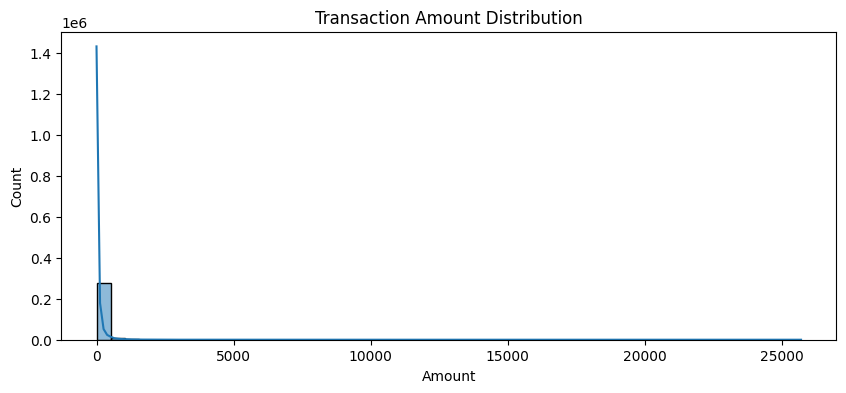

In [23]:
# Step 7: Feature distributions
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

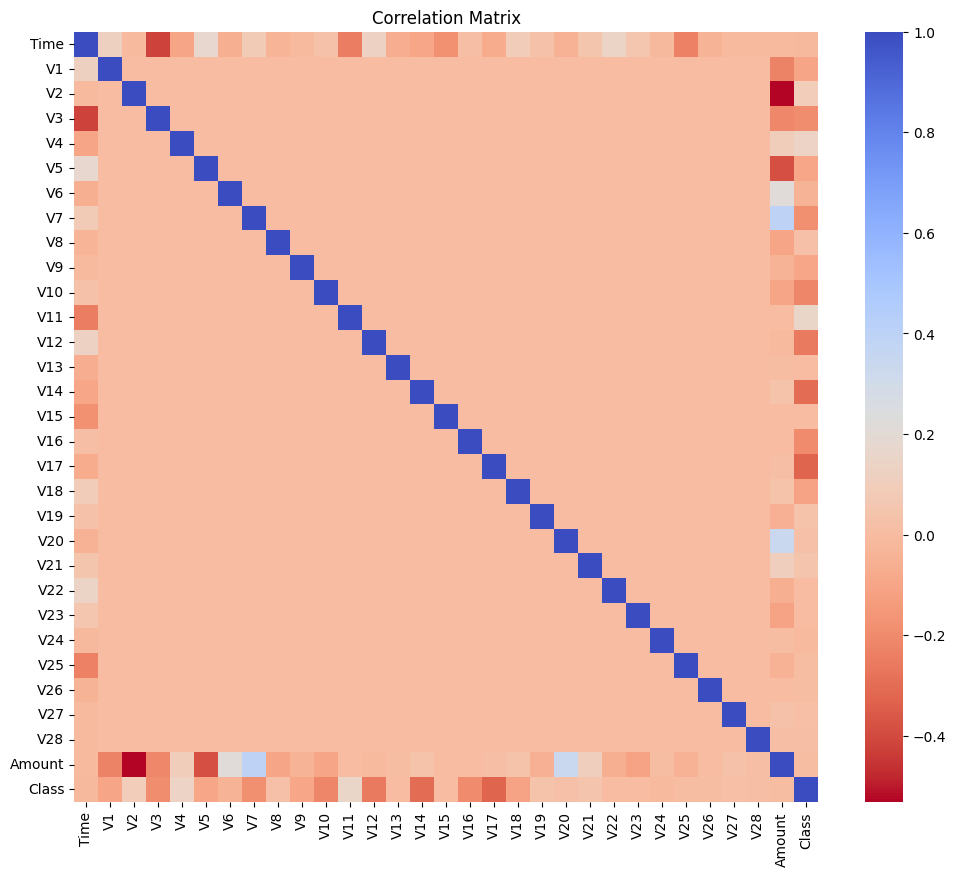

In [24]:

# Step 8: Correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm_r', annot=False)
plt.title('Correlation Matrix')
plt.show()

In [25]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

if 'Amount' in df.columns:
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
else:
    print("Column 'Amount' not found.")

if 'Time' in df.columns:
    df['Time_scaled'] = scaler.fit_transform(df[['Time']])
else:
    print("Column 'Time' not found.")



In [26]:
# Step 10: Prepare features and target
X = df.drop(['Class', 'Amount', 'Time'], axis=1, errors='ignore')
y = df['Class']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
print("Columns in df before dropping:", df.columns.tolist())

X shape: (284807, 30)
y distribution:
 Class
0    284315
1       492
Name: count, dtype: int64
Columns in df before dropping: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_scaled', 'Time_scaled']


Text(0.5, 1.0, 'Fraud vs. Non-Fraud in PCA Feature Space (V1 vs V2)')

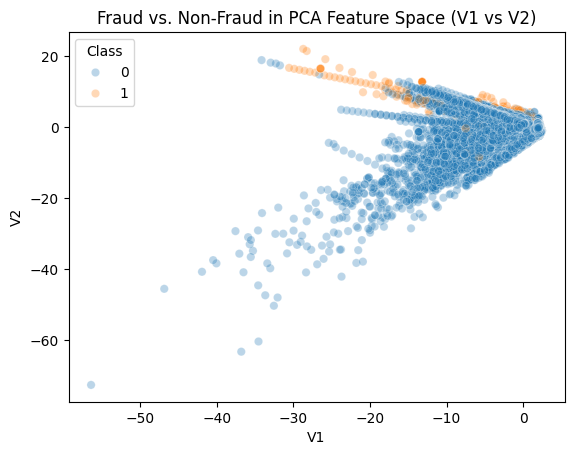

In [27]:
#Visualize Fraud vs. Non-Fraud in PCA Space
import seaborn as sns
sns.scatterplot(data=df, x='V1', y='V2', hue='Class', alpha=0.3)
plt.title("Fraud vs. Non-Fraud in PCA Feature Space (V1 vs V2)")

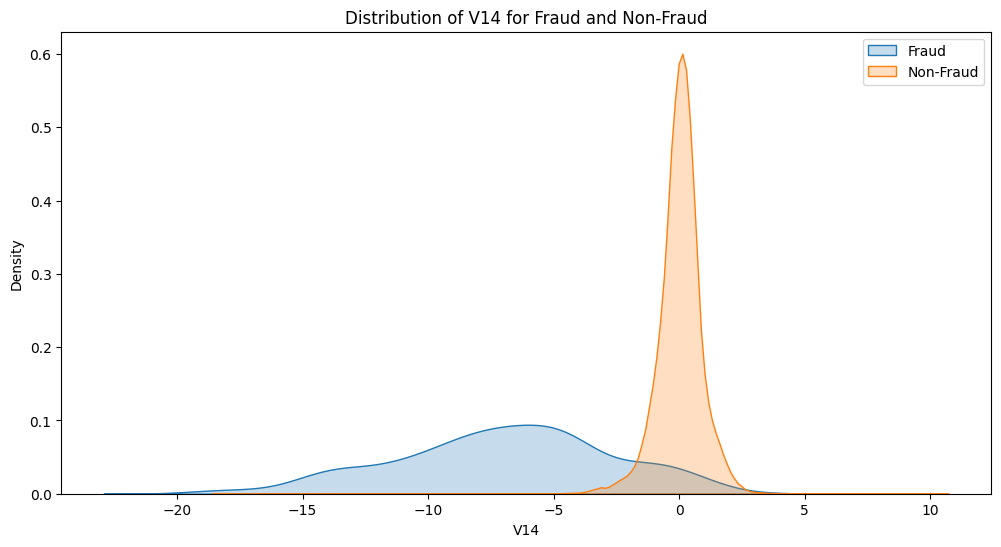

In [28]:
#Distibution Comparison of Key Features
fraud = df[df['Class'] == 1]
nonfraud = df[df['Class'] == 0]

plt.figure(figsize=(12,6))
sns.kdeplot(fraud['V14'], label='Fraud', fill=True)
sns.kdeplot(nonfraud['V14'], label='Non-Fraud', fill=True)
plt.title("Distribution of V14 for Fraud and Non-Fraud")
plt.legend()

<Axes: title={'center': 'Correlation with Fraud Label'}>

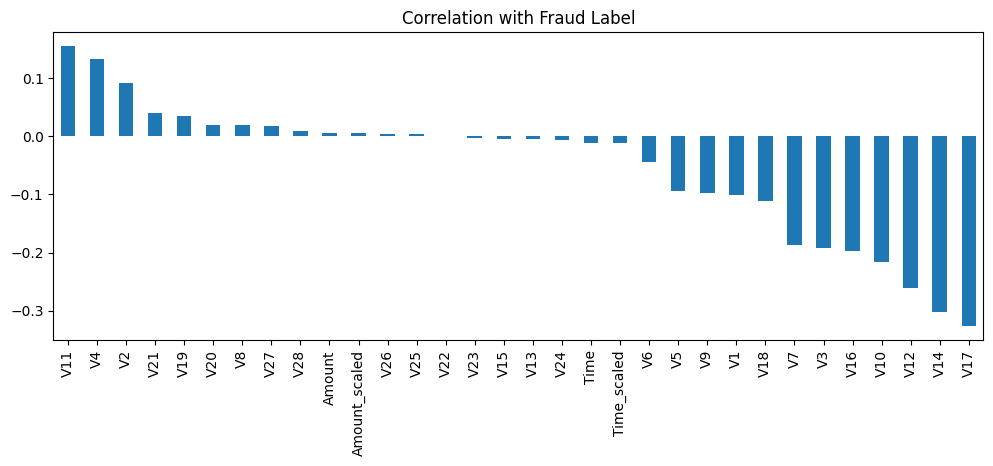

In [29]:
#Feature correlation with target
correlations = df.corr()['Class'].drop('Class')
correlations.sort_values(ascending=False).plot(kind='bar', figsize=(12,4), title='Correlation with Fraud Label')

In [30]:
#Check imbalance ratio
fraud_ratio = y.sum() / len(y)
print(f"Fraud ratio: {fraud_ratio:.5f}")

Fraud ratio: 0.00173


In [31]:
print(y.value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [32]:
#Save cleaned data
df.to_csv('/content/drive/MyDrive/ML_Datasets/cleaned_creditcard.csv', index=False)